# UCI Breast Cancer Wisconsin — 6 Classification Models

এই notebook-এ **UCI Breast Cancer dataset** ব্যবহার করে নিচের ৬টি classification model train ও evaluate করা হবে:

1. RandomForestClassifier
2. AdaBoostClassifier
3. XGBClassifier
4. CatBoostClassifier
5. LGBMClassifier
6. GradientBoostingClassifier

Evaluation:
- Accuracy comparison visualization
- Metrics matrix / heatmap
- Classification report
- Confusion matrix visualization
- ROC curve
- ROC-AUC score
- Best model selection

> Target: `diagnosis` — **M (Malignant)** = 1, **B (Benign)** = 0


In [1]:
# If needed, install these packages
# !pip install -U scikit-learn xgboost catboost lightgbm seaborn matplotlib pandas numpy


# Import Library

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, auc, precision_score, recall_score, f1_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
# Load dataset
df = pd.read_csv("uci breast cancer dataset.csv")

print("Shape:", df.shape)
display(df.head())


Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Basic inspection
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
display(df["diagnosis"].value_counts())


Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values:


Unnamed: 32                569
compactness_se               0
fractal_dimension_worst      0
symmetry_worst               0
concave points_worst         0
concavity_worst              0
compactness_worst            0
smoothness_worst             0
area_worst                   0
perimeter_worst              0
dtype: int64


Target distribution:


diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
# Data cleaning
# id is an identifier, not a useful predictive feature.
# Unnamed: 32 is an empty column in the standard UCI dataset.

data = df.drop(columns=["id", "Unnamed: 32"], errors="ignore").copy()

# Encode target
data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

print("After cleaning:", data.shape)
display(data.head())


After cleaning: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Separate features and target
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Stratified split keeps the class ratio similar in train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


X shape: (569, 30)
y shape: (569,)
Train: (455, 30)
Test : (114, 30)


In [7]:
# Feature scaling
# Tree-based models do not strictly require scaling, but using one
# common scaled feature matrix keeps the workflow consistent.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


In [8]:
# Define six models

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_seed=RANDOM_STATE
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        verbosity=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

print("Models:", list(models.keys()))


Models: ['Random Forest', 'AdaBoost', 'XGBoost', 'CatBoost', 'LightGBM', 'Gradient Boosting']


In [9]:
# Train all models and collect predictions/probabilities

results = []
predictions = {}
probabilities = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob
    fitted_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9737,1.0,0.9286,0.963,0.9980
1,AdaBoost,0.9737,1.0,0.9286,0.963,0.9861
2,XGBoost,0.9649,1.0,0.9048,0.950,0.9927
3,CatBoost,0.9649,1.0,0.9048,0.950,0.9990
4,LightGBM,0.9649,1.0,0.9048,0.950,0.9970
5,Gradient Boosting,0.9649,1.0,0.9048,0.950,0.9940


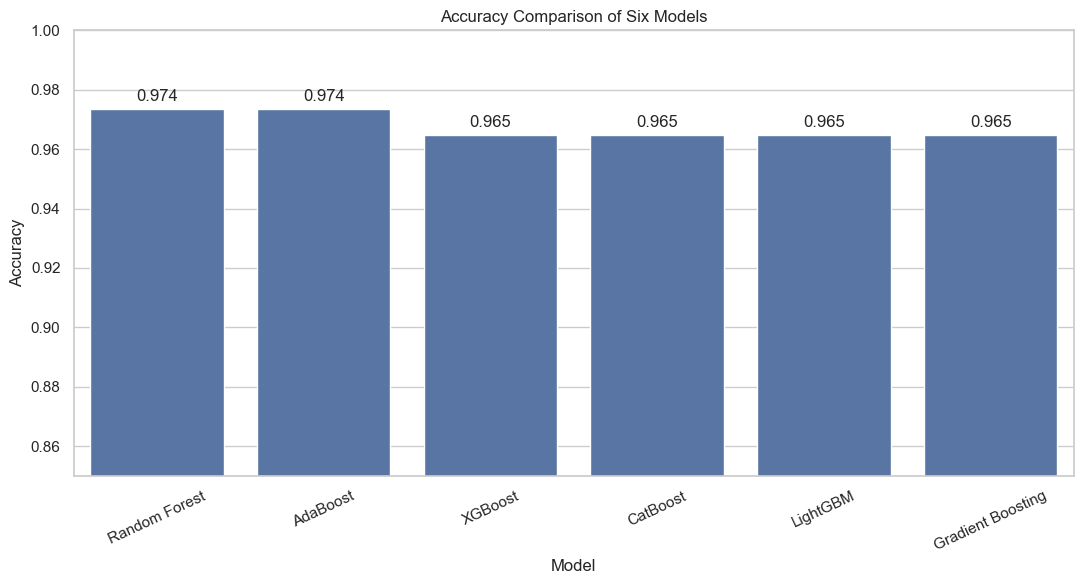

In [10]:
# 1. Accuracy visualization

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Six Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()


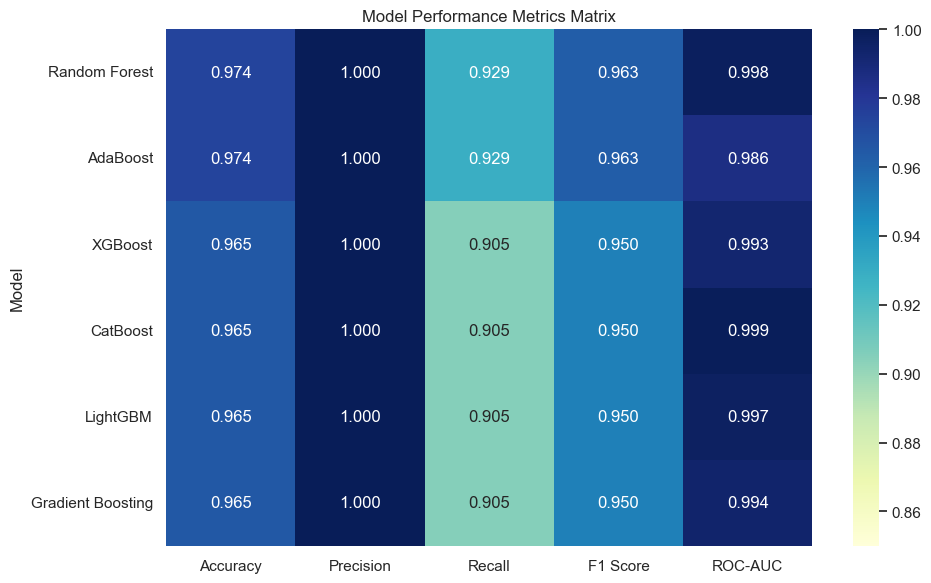

In [11]:
# 2. Metrics matrix visualization

metrics_matrix = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

plt.figure(figsize=(10, 6))
sns.heatmap(
    metrics_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.85,
    vmax=1.0
)

plt.title("Model Performance Metrics Matrix")
plt.tight_layout()
plt.show()


In [12]:
# 3. Classification reports

for name in models.keys():
    print("=" * 75)
    print(f"CLASSIFICATION REPORT — {name}")
    print("=" * 75)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["Benign (B)", "Malignant (M)"],
            digits=4
        )
    )


CLASSIFICATION REPORT — Random Forest
               precision    recall  f1-score   support

   Benign (B)     0.9600    1.0000    0.9796        72
Malignant (M)     1.0000    0.9286    0.9630        42

     accuracy                         0.9737       114
    macro avg     0.9800    0.9643    0.9713       114
 weighted avg     0.9747    0.9737    0.9735       114

CLASSIFICATION REPORT — AdaBoost
               precision    recall  f1-score   support

   Benign (B)     0.9600    1.0000    0.9796        72
Malignant (M)     1.0000    0.9286    0.9630        42

     accuracy                         0.9737       114
    macro avg     0.9800    0.9643    0.9713       114
 weighted avg     0.9747    0.9737    0.9735       114

CLASSIFICATION REPORT — XGBoost
               precision    recall  f1-score   support

   Benign (B)     0.9474    1.0000    0.9730        72
Malignant (M)     1.0000    0.9048    0.9500        42

     accuracy                         0.9649       114
    macro

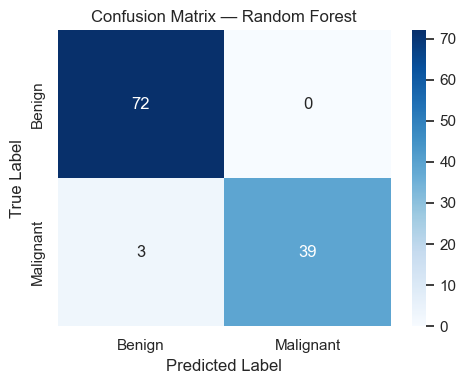

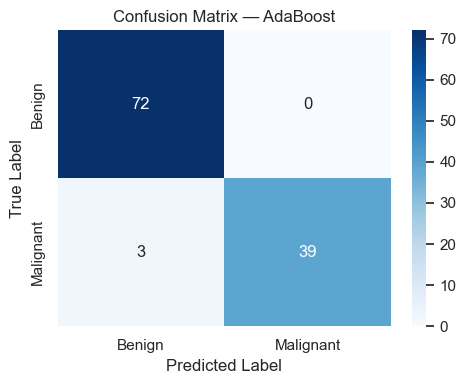

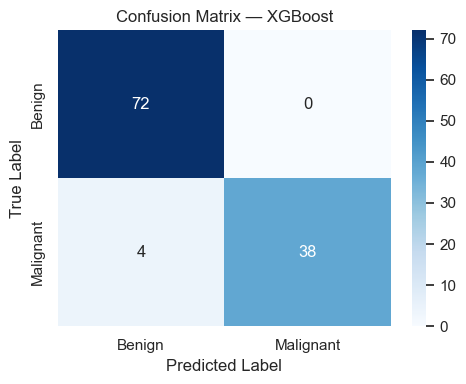

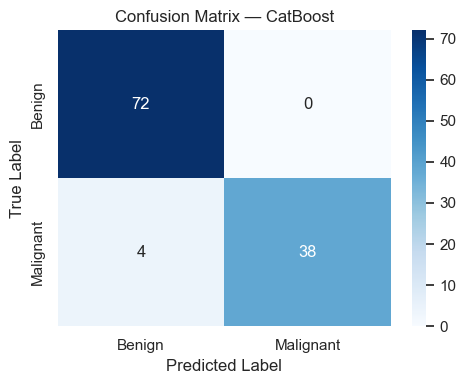

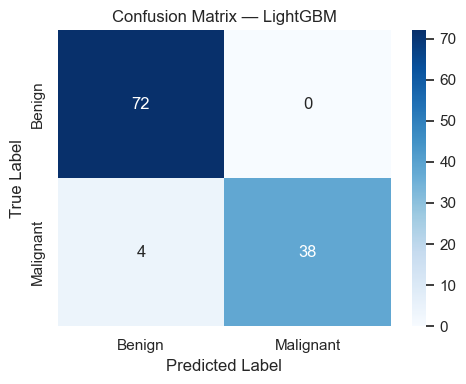

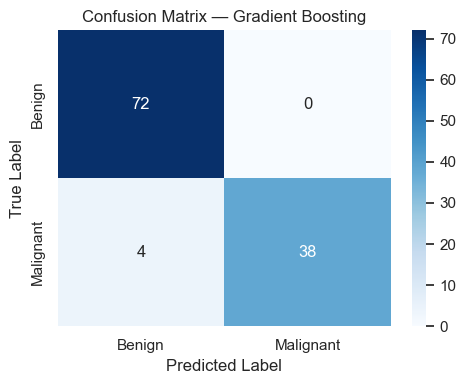

In [13]:
# 4. Confusion matrix for every model

for name in models.keys():
    cm = confusion_matrix(y_test, predictions[name])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


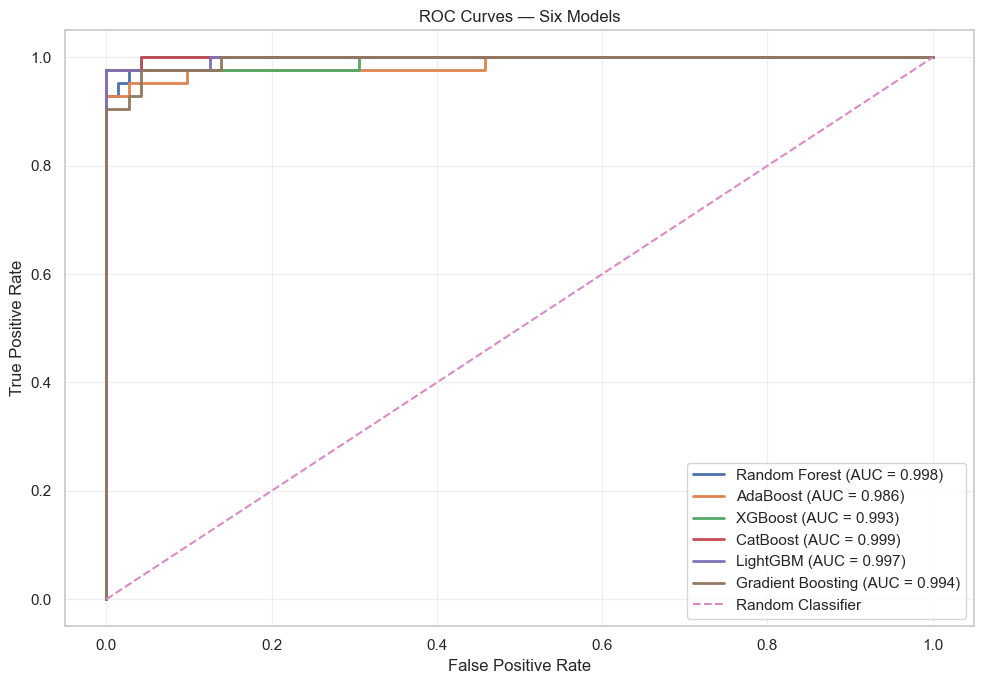

In [14]:
# 5. Combined ROC curve

plt.figure(figsize=(10, 7))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curves — Six Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


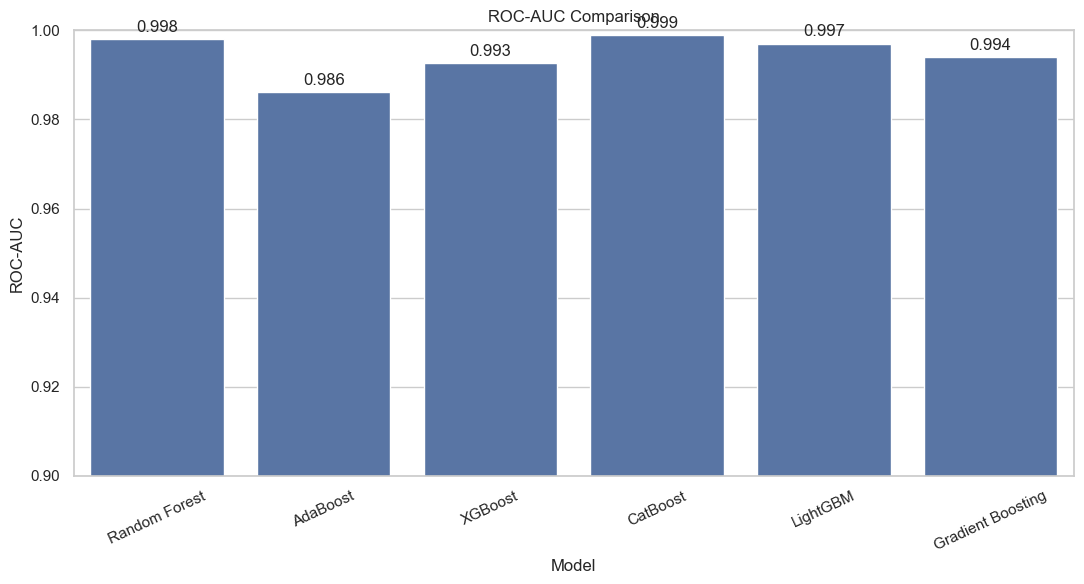

In [15]:
# 6. Individual ROC-AUC values

roc_auc_df = results_df[["Model", "ROC-AUC"]].copy()

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=roc_auc_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()


In [16]:
# 7. Best model according to Accuracy

best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]
best_auc = results_df.iloc[0]["ROC-AUC"]

print(f"Best model by Accuracy: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"ROC-AUC : {best_auc:.4f}")

print("\nDetailed classification report:")
print(
    classification_report(
        y_test,
        predictions[best_model_name],
        target_names=["Benign (B)", "Malignant (M)"],
        digits=4
    )
)


Best model by Accuracy: Random Forest
Accuracy: 0.9737
ROC-AUC : 0.9980

Detailed classification report:
               precision    recall  f1-score   support

   Benign (B)     0.9600    1.0000    0.9796        72
Malignant (M)     1.0000    0.9286    0.9630        42

     accuracy                         0.9737       114
    macro avg     0.9800    0.9643    0.9713       114
 weighted avg     0.9747    0.9737    0.9735       114



In [17]:
# 8. Prediction function for a new patient

def predict_breast_cancer(input_data, model_name=best_model_name):
    """
    input_data:
        A pandas DataFrame containing the same 30 feature columns
        used during training.

    Returns:
        predicted class and probability.
    """
    if not isinstance(input_data, pd.DataFrame):
        raise TypeError("input_data must be a pandas DataFrame")

    missing = set(X.columns) - set(input_data.columns)
    if missing:
        raise ValueError(f"Missing feature columns: {sorted(missing)}")

    input_data = input_data[X.columns]
    input_scaled = scaler.transform(input_data)

    model = fitted_models[model_name]

    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0, 1]

    label = "Malignant (M)" if pred == 1 else "Benign (B)"

    return {
        "model": model_name,
        "prediction": label,
        "malignant_probability": float(prob),
        "benign_probability": float(1 - prob)
    }

print("Prediction function created.")


Prediction function created.


## Important notes

- এই dataset-এ 569টি sample এবং 30টি numeric feature আছে।
- `id` এবং `Unnamed: 32` model-এর feature হিসেবে ব্যবহার করা হয়নি।
- Target `diagnosis`: B = 0, M = 1.
- Train/Test split = 80% / 20%, এবং `stratify=y` ব্যবহার করা হয়েছে।
- এখানে reported accuracy হলো এই নির্দিষ্ট 80/20 split-এর test accuracy; এটি অন্য split বা cross-validation-এ পরিবর্তিত হতে পারে।
- Medical application-এ শুধু accuracy দেখে model নির্বাচন করা উচিত নয়; **Recall/Sensitivity, Precision, F1 এবং ROC-AUC**-ও গুরুত্বপূর্ণ।
